In [50]:
def set_all_seeds(seed=42):
    """Set seeds for reproducibility"""
    import numpy as np
    import random
    import os
    import torch
    import tensorflow as tf
    
    # Python
    random.seed(seed)
    
    # Numpy
    np.random.seed(seed)
    
    # PyTorch (if available)
    try:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
    except:
        pass
    
    # TensorFlow (if available)
    try:
        tf.random.set_seed(seed)
    except:
        pass
    
    # Set Python hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)

# Set seeds for reproducibility
set_all_seeds(42)

# Import necessary libraries
%pip install prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
from tqdm import tqdm
import warnings
import inspect

warnings.filterwarnings('ignore')



Note: you may need to restart the kernel to use updated packages.


In [51]:
# Load the data
weather_train_path = r"D:\My Files R\KDU\Data_Crunch_38\Final\train_dataW.csv"
price_train_path = r"D:\My Files R\KDU\Data_Crunch_38\Final\train_dataP.csv"
weather_eval_path = r"D:\My Files R\KDU\Data_Crunch_38\Datasets\eval_dataW.csv"
price_eval_path = r"D:\My Files R\KDU\Data_Crunch_38\Datasets\eval_dataP.csv"

# Load datasets
weather_train = pd.read_csv(weather_train_path)
price_train = pd.read_csv(price_train_path)
weather_eval = pd.read_csv(weather_eval_path)
price_eval = pd.read_csv(price_eval_path)

# Convert date columns to datetime
weather_train['Date'] = pd.to_datetime(weather_train['Date'])
weather_eval['Date'] = pd.to_datetime(weather_eval['Date'])
if 'Date' in price_train.columns:
    price_train['Date'] = pd.to_datetime(price_train['Date'])
if 'Date' in price_eval.columns:
    price_eval['Date'] = pd.to_datetime(price_eval['Date'])


In [52]:
# Data exploration and preprocessing
def explore_data(weather_df, price_df):
    print(f"Weather data shape: {weather_df.shape}")
    print(f"Price data shape: {price_df.shape}")
    
    print("\nWeather data sample:")
    print(weather_df.head())
    
    print("\nPrice data sample:")
    print(price_df.head())
    
    # Check for missing values
    print("\nMissing values in weather data:")
    print(weather_df.isnull().sum())
    
    print("\nMissing values in price data:")
    print(price_df.isnull().sum())
    
    # Check unique regions and commodities
    print(f"\nUnique regions in weather data: {weather_df['Region'].nunique()}")
    if 'Region' in price_df.columns:
        print(f"Unique regions in price data: {price_df['Region'].nunique()}")
    
    if 'Commodity' in price_df.columns:
        print(f"Unique commodities in price data: {price_df['Commodity'].nunique()}")
    
    # Check date ranges
    print(f"\nWeather data date range: {weather_df['Date'].min()} to {weather_df['Date'].max()}")
    if 'Date' in price_df.columns:
        print(f"Price data date range: {price_df['Date'].min()} to {price_df['Date'].max()}")


In [53]:
# Explore training data
explore_data(weather_train, price_train)


Weather data shape: (181730, 6)
Price data shape: (181730, 5)

Weather data sample:
        Date        Region  Temperature (K)  Rainfall (mm)  Humidity (%)  \
0 2040-01-01  Mystic Falls           307.55          474.5          61.3   
1 2040-01-01       Olympus           301.35          106.6          53.6   
2 2040-01-01    Metropolis           306.15          266.3          93.9   
3 2040-01-01       Arcadia           304.15          222.2          81.0   
4 2040-01-01       Elysium           304.85          492.1          61.7   

   Crop Yield Impact Score  
0                     1.89  
1                     1.74  
2                     2.18  
3                     1.68  
4                     1.89  

Price data sample:
        Date        Region Commodity  Price per Unit (Silver Drachma/kg)  \
0 2040-01-01  Mystic Falls  Plantain                              296.37   
1 2040-01-01       Olympus    Loquat                              394.21   
2 2040-01-01    Metropolis    Loquat 

In [54]:
# Function to identify market days for each region-commodity pair
def identify_market_days(price_df):
    """
    Identifies the pattern of market days for each region-commodity pair
    Returns a dictionary with region-commodity keys and market day intervals
    """
    market_patterns = {}
    
    # Group by region and commodity
    if 'Date' not in price_df.columns:
        # If Date is not in columns, we need to determine how dates are stored
        # For this example, I'll assume there's a date column that needs to be identified
        date_cols = [col for col in price_df.columns if 'date' in col.lower() or 'day' in col.lower()]
        if date_cols:
            date_col = date_cols[0]
            price_df['Date'] = pd.to_datetime(price_df[date_col])
        else:
            print("Cannot identify date column in price data")
            return market_patterns
    
    # Get unique region-commodity pairs
    if 'Region' in price_df.columns and 'Commodity' in price_df.columns:
        region_commodity_pairs = price_df[['Region', 'Commodity']].drop_duplicates()
        
        for _, row in tqdm(region_commodity_pairs.iterrows(), total=len(region_commodity_pairs)):
            region = row['Region']
            commodity = row['Commodity']
            
            # Filter data for this region-commodity pair
            pair_data = price_df[(price_df['Region'] == region) & 
                                (price_df['Commodity'] == commodity)].sort_values('Date')
            
            if len(pair_data) > 1:
                # Calculate differences between consecutive dates
                pair_data = pair_data.reset_index(drop=True)
                date_diffs = [(pair_data['Date'].iloc[i+1] - pair_data['Date'].iloc[i]).days 
                             for i in range(len(pair_data)-1)]
                
                # Find the most common difference (market interval)
                if date_diffs:
                    from collections import Counter
                    counter = Counter(date_diffs)
                    most_common_diff = counter.most_common(1)[0][0]
                    
                    # Store the interval and last market date
                    market_patterns[(region, commodity)] = {
                        'interval': most_common_diff,
                        'last_date': pair_data['Date'].iloc[-1]
                    }
    
    print(f"Identified market patterns for {len(market_patterns)} region-commodity pairs")
    return market_patterns


In [55]:
# Function to create lag features from weather data
def create_weather_features(weather_df, price_df, market_patterns):
    """
    Creates weather features with appropriate lags for each region-commodity pair
    """
    # Create a dictionary to store features for each region-commodity pair
    features_dict = {}
    
    # Get unique region-commodity pairs
    if 'Region' in price_df.columns and 'Commodity' in price_df.columns:
        region_commodity_pairs = price_df[['Region', 'Commodity']].drop_duplicates()
        
        for _, row in tqdm(region_commodity_pairs.iterrows(), total=len(region_commodity_pairs)):
            region = row['Region']
            commodity = row['Commodity']
            
            # Filter price data for this region-commodity pair
            price_data = price_df[(price_df['Region'] == region) & 
                                 (price_df['Commodity'] == commodity)].sort_values('Date')
            
            # Filter weather data for this region
            weather_data = weather_df[weather_df['Region'] == region].sort_values('Date')
            
            # If we have multiple weather readings per day, aggregate them
            weather_daily = weather_data.groupby('Date').agg({
                'Temperature (K)': 'mean',
                'Rainfall (mm)': 'sum',
                'Humidity (%)': 'mean',
                'Crop Yield Impact Score': 'mean'
            }).reset_index()
            
            # Create lag features (1 week to 4 weeks)
            for lag in range(1, 29):  # Up to 4 weeks of daily lags
                weather_daily[f'Temp_lag_{lag}'] = weather_daily['Temperature (K)'].shift(lag)
                weather_daily[f'Rain_lag_{lag}'] = weather_daily['Rainfall (mm)'].shift(lag)
                weather_daily[f'Humidity_lag_{lag}'] = weather_daily['Humidity (%)'].shift(lag)
                weather_daily[f'Impact_lag_{lag}'] = weather_daily['Crop Yield Impact Score'].shift(lag)
            
            # Create rolling window features
            for window in [7, 14, 21, 28]:  # 1, 2, 3, 4 weeks
                weather_daily[f'Temp_roll_{window}'] = weather_daily['Temperature (K)'].rolling(window=window).mean()
                weather_daily[f'Rain_roll_{window}'] = weather_daily['Rainfall (mm)'].rolling(window=window).sum()
                weather_daily[f'Humidity_roll_{window}'] = weather_daily['Humidity (%)'].rolling(window=window).mean()
                weather_daily[f'Impact_roll_{window}'] = weather_daily['Crop Yield Impact Score'].rolling(window=window).mean()
            
            # Merge with price data
            if 'Date' in price_data.columns:
                merged_data = pd.merge(price_data, weather_daily, on='Date', how='left')
                
                # Store in dictionary
                features_dict[(region, commodity)] = merged_data
    
    return features_dict


In [56]:
# Function to predict future market days
def predict_future_market_days(region, commodity, current_date, market_patterns):
    """
    Predicts the next 4 market days for a given region-commodity pair
    """
    if (region, commodity) in market_patterns:
        pattern = market_patterns[(region, commodity)]
        interval = pattern['interval']
        last_date = pattern['last_date']
        
        # Convert current_date to datetime if it's not already
        if not isinstance(current_date, pd.Timestamp):
            current_date = pd.to_datetime(current_date)
        
        # Calculate days since last market day
        days_since_last = (current_date - last_date).days
        
        # Calculate days until next market day
        days_until_next = interval - (days_since_last % interval)
        if days_until_next == interval:
            days_until_next = 0
        
        # Calculate next 4 market days
        next_market_days = [
            current_date + timedelta(days=days_until_next + i * interval)
            for i in range(4)
        ]
        
        return next_market_days
    else:
        print(f"No market pattern found for {region} - {commodity}")
        return None


In [57]:
# Build the hybrid forecasting model
class HybridForecastingModel:
    def __init__(self):
        self.market_patterns = {}
        self.prophet_models = {}
        self.lgb_models = {}
        self.scalers = {}
        
    def fit(self, weather_train, price_train):
        # Identify market patterns
        self.market_patterns = identify_market_days(price_train)
        
        # Create features
        features_dict = create_weather_features(weather_train, price_train, self.market_patterns)
        
        # Train models for each region-commodity pair
        for (region, commodity), data in tqdm(features_dict.items(), desc="Training models"):
            # Skip if not enough data
            if len(data) < 10:
                continue
                
            # Prepare data for Prophet (first stage)
            prophet_data = data[['Date', 'Price per Unit (Silver Drachma/kg)']].rename(
                columns={'Date': 'ds', 'Price per Unit (Silver Drachma/kg)': 'y'})
            
            # Train Prophet model
            prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
            try:
                prophet_model.fit(prophet_data)
                self.prophet_models[(region, commodity)] = prophet_model
            except:
                print(f"Error fitting Prophet model for {region} - {commodity}")
                continue
            
            # Generate Prophet predictions for training data
            prophet_forecast = prophet_model.predict(prophet_data[['ds']])
            
            # Merge Prophet predictions with original data
            data['prophet_pred'] = prophet_forecast['yhat'].values
            data['prophet_trend'] = prophet_forecast['trend'].values
            
            # Prepare data for LightGBM (second stage)
            # Select features
            feature_cols = [col for col in data.columns if any(x in col for x in ['Temp', 'Rain', 'Humidity', 'Impact', 'prophet'])]
            feature_cols = [col for col in feature_cols if 'lag' in col or 'roll' in col or 'prophet' in col]
            
            # Remove rows with NaN (due to lags and rolling windows)
            lgb_data = data.dropna(subset=feature_cols + ['Price per Unit (Silver Drachma/kg)'])
            
            if len(lgb_data) < 10:
                continue
                
            # Scale features
            X = lgb_data[feature_cols]
            y = lgb_data['Price per Unit (Silver Drachma/kg)']
            
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            self.scalers[(region, commodity)] = scaler
            
            # Train LightGBM model
            lgb_train = lgb.Dataset(X_scaled, y)
            
            params = {
                'objective': 'regression',
                'metric': 'mae',
                'num_leaves': 31,
                'learning_rate': 0.05,
                'feature_fraction': 0.9,
                'bagging_fraction': 0.8,
                'bagging_freq': 5,
                'verbose': -1
            }
            
            lgb_model = lgb.train(params, lgb_train, num_boost_round=100)
            self.lgb_models[(region, commodity)] = lgb_model
            
        print(f"Trained models for {len(self.lgb_models)} region-commodity pairs")
    
    def predict(self, region, commodity, current_date, weather_data):
        """
        Predicts prices for the next 4 market days for a given region-commodity pair
        """
        if (region, commodity) not in self.market_patterns or \
           (region, commodity) not in self.prophet_models or \
           (region, commodity) not in self.lgb_models:
            print(f"No model available for {region} - {commodity}")
            return None
        
        # Get next 4 market days
        next_market_days = predict_future_market_days(region, commodity, current_date, self.market_patterns)
        if not next_market_days:
            return None
        
        # Prepare data for Prophet prediction
        future_prophet = pd.DataFrame({'ds': next_market_days})
        prophet_forecast = self.prophet_models[(region, commodity)].predict(future_prophet)
        
        # Filter and aggregate weather data for this region
        region_weather = weather_data[weather_data['Region'] == region].copy()
        region_weather_daily = region_weather.groupby('Date').agg({
            'Temperature (K)': 'mean',
            'Rainfall (mm)': 'sum',
            'Humidity (%)': 'mean',
            'Crop Yield Impact Score': 'mean'
        }).reset_index()
        
        # Create lag features for prediction dates
        all_dates = pd.date_range(start=region_weather_daily['Date'].min(), end=next_market_days[-1])
        full_weather = pd.DataFrame({'Date': all_dates})
        full_weather = pd.merge(full_weather, region_weather_daily, on='Date', how='left')
        
        # Forward fill missing weather data (if any)
        full_weather = full_weather.ffill()
        
        # Create lag features
        for lag in range(1, 29):  # Up to 4 weeks of daily lags
            full_weather[f'Temp_lag_{lag}'] = full_weather['Temperature (K)'].shift(lag)
            full_weather[f'Rain_lag_{lag}'] = full_weather['Rainfall (mm)'].shift(lag)
            full_weather[f'Humidity_lag_{lag}'] = full_weather['Humidity (%)'].shift(lag)
            full_weather[f'Impact_lag_{lag}'] = full_weather['Crop Yield Impact Score'].shift(lag)
        
        # Create rolling window features
        for window in [7, 14, 21, 28]:  # 1, 2, 3, 4 weeks
            full_weather[f'Temp_roll_{window}'] = full_weather['Temperature (K)'].rolling(window=window).mean()
            full_weather[f'Rain_roll_{window}'] = full_weather['Rainfall (mm)'].rolling(window=window).sum()
            full_weather[f'Humidity_roll_{window}'] = full_weather['Humidity (%)'].rolling(window=window).mean()
            full_weather[f'Impact_roll_{window}'] = full_weather['Crop Yield Impact Score'].rolling(window=window).mean()
        
        # Prepare prediction data for each market day
        predictions = []
        confidence_levels = []
        
        for market_day in next_market_days:
            # Get weather features for this market day
            day_weather = full_weather[full_weather['Date'] == market_day]
            
            if len(day_weather) == 0:
                print(f"No weather data available for {market_day}")
                predictions.append(None)
                confidence_levels.append("Low")
                continue
            
            # Get Prophet prediction
            prophet_pred = prophet_forecast[prophet_forecast['ds'] == market_day]
            if len(prophet_pred) == 0:
                print(f"No Prophet prediction for {market_day}")
                predictions.append(None)
                confidence_levels.append("Low")
                continue
            
            # Combine Prophet prediction with weather features
            day_weather['prophet_pred'] = prophet_pred['yhat'].values[0]
            day_weather['prophet_trend'] = prophet_pred['trend'].values[0]
            
            # Select features for LightGBM
            feature_cols = [col for col in day_weather.columns if any(x in col for x in ['Temp', 'Rain', 'Humidity', 'Impact', 'prophet'])]
            feature_cols = [col for col in feature_cols if 'lag' in col or 'roll' in col or 'prophet' in col]
            
            # Check if we have all required features
            if any(day_weather[feature_cols].isna().any()):
                # If we're missing some features, use only Prophet prediction
                predictions.append(prophet_pred['yhat'].values[0])
                confidence_levels.append("Low (Prophet only)")
                continue
            
            # Scale features
            X = day_weather[feature_cols]
            X_scaled = self.scalers[(region, commodity)].transform(X)
            
            # Make LightGBM prediction
            lgb_pred = self.lgb_models[(region, commodity)].predict(X_scaled)[0]
            
            # Determine confidence level based on prediction date
            days_ahead = (market_day - pd.to_datetime(current_date)).days
            if days_ahead <= 7:
                confidence = "High"
            elif days_ahead <= 14:
                confidence = "Medium-High"
            elif days_ahead <= 21:
                confidence = "Medium"
            else:
                confidence = "Medium-Low"
            
            predictions.append(lgb_pred)
            confidence_levels.append(confidence)
        
        # Create result dataframe
        result = pd.DataFrame({
            'Market Day': next_market_days,
            'Predicted Price (Silver Drachma/kg)': predictions,
            'Confidence': confidence_levels
        })
        
        return result
    
    def evaluate(self, weather_eval, price_eval):
        """
        Evaluates the model on evaluation data
        """
        # Create features for evaluation
        eval_features = create_weather_features(weather_eval, price_eval, self.market_patterns)
        
        # Track errors
        errors = []
        
        # Evaluate each region-commodity pair
        for (region, commodity), data in eval_features.items():
            if (region, commodity) not in self.prophet_models or \
               (region, commodity) not in self.lgb_models:
                continue
            
            # Get actual prices
            actual_prices = data['Price per Unit (Silver Drachma/kg)']
            
            # Generate Prophet predictions
            prophet_data = data[['Date']].rename(columns={'Date': 'ds'})
            prophet_forecast = self.prophet_models[(region, commodity)].predict(prophet_data)
            
            # Combine Prophet prediction with features
            data['prophet_pred'] = prophet_forecast['yhat'].values
            data['prophet_trend'] = prophet_forecast['trend'].values
            
            # Select features for LightGBM
            feature_cols = [col for col in data.columns if any(x in col for x in ['Temp', 'Rain', 'Humidity', 'Impact', 'prophet'])]
            feature_cols = [col for col in feature_cols if 'lag' in col or 'roll' in col or 'prophet' in col]
            
            # Remove rows with NaN
            eval_data = data.dropna(subset=feature_cols + ['Price per Unit (Silver Drachma/kg)'])
            
            if len(eval_data) < 5:
                continue
                
            # Scale features
            X = eval_data[feature_cols]
            y = eval_data['Price per Unit (Silver Drachma/kg)']
            
            X_scaled = self.scalers[(region, commodity)].transform(X)
            
            # Make predictions
            lgb_preds = self.lgb_models[(region, commodity)].predict(X_scaled)
            
            # Calculate errors
            mae = mean_absolute_error(y, lgb_preds)
            rmse = np.sqrt(mean_squared_error(y, lgb_preds))
            
            errors.append({
                'Region': region,
                'Commodity': commodity,
                'MAE': mae,
                'RMSE': rmse,
                'Samples': len(eval_data)
            })
        
        # Create error summary
        error_df = pd.DataFrame(errors)
        print(f"Average MAE: {error_df['MAE'].mean():.2f}")
        print(f"Average RMSE: {error_df['RMSE'].mean():.2f}")
        
        return error_df


In [58]:
# Function to demonstrate the model usage
def demonstrate_model(model, region, commodity, current_date, weather_data):
    """
    Demonstrates how to use the model for a specific region and commodity
    """
    print(f"Predicting prices for {commodity} in {region} from {current_date}")
    
    # Make prediction
    predictions = model.predict(region, commodity, current_date, weather_data)
    
    if predictions is not None:
        print("\nPredicted prices for the next 4 market days:")
        for _, row in predictions.iterrows():
            print(f"Market Day: {row['Market Day'].strftime('%Y-%m-%d')}")
            print(f"Predicted Price: {row['Predicted Price (Silver Drachma/kg)']:.2f} Silver Drachma/kg")
            print(f"Confidence: {row['Confidence']}")
            print("-" * 40)
    else:
        print("Could not generate predictions.")


In [59]:
# Main execution
def main():
    # Train the model
    model = HybridForecastingModel()
    print("Training model...")
    model.fit(weather_train, price_train)
    
    # Evaluate the model
    print("\nEvaluating model...")
    evaluation = model.evaluate(weather_eval, price_eval)
    
    # Display evaluation results
    print("\nEvaluation results by region and commodity:")
    print(evaluation.sort_values('MAE'))
    
    # Demonstrate prediction for a specific region and commodity
    # Get a sample region and commodity from the data
    sample_region = price_train['Region'].iloc[0] if 'Region' in price_train.columns else None
    sample_commodity = price_train['Commodity'].iloc[0] if 'Commodity' in price_train.columns else None
    
    if sample_region and sample_commodity:
        # Use the last date in the evaluation data as the current date
        current_date = weather_eval['Date'].max()
        
        print("\nDemonstration of model prediction:")
        demonstrate_model(model, sample_region, sample_commodity, current_date, weather_eval)
    
    # Create a function for Magnus to use
    def predict_for_magnus(region, commodity, current_date):
        """
        Function for Magnus to predict prices for a specific region and commodity
        """
        return model.predict(region, commodity, current_date, weather_eval)
    
    print("\nModel training and evaluation complete.")
    print("Use the predict_for_magnus() function to make predictions for specific regions and commodities.")
    
    return model, predict_for_magnus

# Run the main function
if __name__ == "__main__":
    model, predict_for_magnus = main()


Training model...


  0%|          | 0/925 [00:00<?, ?it/s]

100%|██████████| 925/925 [00:25<00:00, 36.16it/s]


Identified market patterns for 925 region-commodity pairs


Training models:   0%|          | 0/925 [00:00<?, ?it/s]02:59:17 - cmdstanpy - INFO - Chain [1] start processing
02:59:17 - cmdstanpy - INFO - Chain [1] done processing
Training models:   0%|          | 1/925 [00:00<04:35,  3.36it/s]02:59:18 - cmdstanpy - INFO - Chain [1] start processing
02:59:18 - cmdstanpy - INFO - Chain [1] done processing
Training models:   0%|          | 2/925 [00:00<04:37,  3.33it/s]02:59:18 - cmdstanpy - INFO - Chain [1] start processing
02:59:18 - cmdstanpy - INFO - Chain [1] done processing
Training models:   0%|          | 3/925 [00:00<04:45,  3.23it/s]02:59:18 - cmdstanpy - INFO - Chain [1] start processing
02:59:18 - cmdstanpy - INFO - Chain [1] done processing
Training models:   0%|          | 4/925 [00:01<04:43,  3.25it/s]02:59:19 - cmdstanpy - INFO - Chain [1] start processing
02:59:19 - cmdstanpy - INFO - Chain [1] done processing
Training models:   1%|          | 5/925 [00:01<05:03,  3.03it/s]02:59:19 - cmdstanpy - INFO - Chain [1] start processing
02

Trained models for 925 region-commodity pairs

Evaluating model...


100%|██████████| 925/925 [01:02<00:00, 14.80it/s]


Average MAE: 8.04
Average RMSE: 13.15

Evaluation results by region and commodity:
           Region       Commodity        MAE       RMSE  Samples
393       Elysium     Red Currant   2.503034   3.536269       26
409      Atlantis       Snow Peas   2.559880   3.868194       22
825     Hogsmeade          Turnip   2.997260   4.534069       22
23     Shangri-La         Pulasan   3.109358   4.453666       26
769      Valhalla          Feijoa   3.204917   4.019232       26
..            ...             ...        ...        ...      ...
773  Emerald City      Bael Fruit  22.144455  50.087419       26
543       Eldoria        Plantain  22.328266  41.286213       28
802    Shangri-La        Rutabaga  34.591683  47.858969       22
299       Arcadia  White Eggplant  35.802337  52.631954       22
887        Avalon         Shallot  43.483082  66.347978       22

[925 rows x 5 columns]

Demonstration of model prediction:
Predicting prices for Plantain in Mystic Falls from 2043-12-31 00:00:00

Pred

In [60]:
# Example of how Magnus would use the model
def magnus_decision_support(region, commodity, current_date, freezing_cost=5, weekly_depreciation_rate=0.1):
    """
    Provides decision support for Magnus on whether to sell fresh or freeze
    
    Parameters:
    - region: Market region
    - commodity: Agricultural product
    - current_date: Date of decision
    - freezing_cost: Cost to freeze per unit (in Silver Drachma)
    - weekly_depreciation_rate: Rate at which frozen produce loses value each week
    
    Returns:
    - DataFrame with profit analysis and recommendation
    """
    # Get price predictions
    predictions = predict_for_magnus(region, commodity, current_date)
    
    if predictions is None or len(predictions) == 0:
        print(f"No predictions available for {commodity} in {region}")
        return None
    
    # Calculate expected profits
    results = []
    
    # Assume current price (fresh price today) is the first predicted price
    current_price = predictions['Predicted Price (Silver Drachma/kg)'].iloc[0]
    
    # Calculate profit for each future market day
    for i, row in predictions.iterrows():
        market_day = row['Market Day']
        predicted_price = row['Predicted Price (Silver Drachma/kg)']
        confidence = row['Confidence']
        
        # Calculate days from current date
        days_ahead = (market_day - pd.to_datetime(current_date)).days
        weeks_ahead = days_ahead / 7
        
        # Calculate depreciation factor
        depreciation_factor = (1 - weekly_depreciation_rate) ** weeks_ahead
        
        # Calculate expected profit
        sell_fresh_profit = current_price
        freeze_profit = (predicted_price * depreciation_factor) - freezing_cost
        
        # Determine confidence factor (higher confidence = more weight)
        if confidence == "High":
            confidence_factor = 1.0
        elif confidence == "Medium-High":
            confidence_factor = 0.85
        elif confidence == "Medium":
            confidence_factor = 0.7
        else:  # Medium-Low or Low
            confidence_factor = 0.5
        
        # Adjust freeze profit by confidence
        risk_adjusted_freeze_profit = freeze_profit * confidence_factor
        
        # Determine recommendation
        if risk_adjusted_freeze_profit > sell_fresh_profit:
            recommendation = "FREEZE"
            profit_increase = risk_adjusted_freeze_profit - sell_fresh_profit
        else:
            recommendation = "SELL FRESH"
            profit_increase = sell_fresh_profit - risk_adjusted_freeze_profit
        
        results.append({
            'Market Day': market_day,
            'Predicted Price': predicted_price,
            'Confidence': confidence,
            'Sell Fresh Profit': sell_fresh_profit,
            'Freeze Profit': freeze_profit,
            'Risk-Adjusted Freeze Profit': risk_adjusted_freeze_profit,
            'Recommendation': recommendation,
            'Expected Profit Increase': profit_increase
        })
    
    # Create result dataframe
    result_df = pd.DataFrame(results)
    
    # Determine overall recommendation
    best_option = result_df.loc[result_df['Risk-Adjusted Freeze Profit'].idxmax()]
    
    if best_option['Recommendation'] == "FREEZE":
        print(f"\n✅ RECOMMENDATION: FREEZE {commodity} and sell on {best_option['Market Day'].strftime('%Y-%m-%d')}")
        print(f"Expected profit increase: {best_option['Expected Profit Increase']:.2f} Silver Drachma/kg")
    else:
        print(f"\n✅ RECOMMENDATION: SELL {commodity} FRESH TODAY")
        print(f"Expected profit: {best_option['Sell Fresh Profit']:.2f} Silver Drachma/kg")
    
    return result_df


In [61]:
# Example usage of the decision support system
sample_region = price_train['Region'].iloc[0]
sample_commodity = price_train['Commodity'].iloc[0]
current_date = weather_eval['Date'].max()

# Only train the model if it doesn't already exist
if 'model' not in globals() or not isinstance(model, HybridForecastingModel):
    print("Training the model first...")
    model, predict_for_magnus = main()
else:
    print("Using existing trained model")

# Get decision support for the sample region and commodity
decision_analysis = magnus_decision_support(
    region=sample_region,
    commodity=sample_commodity,
    current_date=current_date,
    freezing_cost=5,
    weekly_depreciation_rate=0.1
)

if decision_analysis is not None:
    print("\nDetailed profit analysis:")
    print(decision_analysis[['Market Day', 'Predicted Price', 'Confidence', 
                            'Sell Fresh Profit', 'Risk-Adjusted Freeze Profit', 
                            'Recommendation']])

Using existing trained model

✅ RECOMMENDATION: SELL Plantain FRESH TODAY
Expected profit: 484.88 Silver Drachma/kg

Detailed profit analysis:
  Market Day  Predicted Price   Confidence  Sell Fresh Profit  \
0 2043-12-31       484.880199         High         484.880199   
1 2044-01-06       358.035791         High         484.880199   
2 2044-01-12       466.217469  Medium-High         484.880199   
3 2044-01-18       390.083075       Medium         484.880199   

   Risk-Adjusted Freeze Profit Recommendation  
0                   479.880199     SELL FRESH  
1                   322.118975     SELL FRESH  
2                   326.550422     SELL FRESH  
3                   204.753845     SELL FRESH  


In [62]:
import os
print(f"Current working directory: {os.getcwd()}")


Current working directory: c:\Users\L E N O V O\Downloads\New folder


In [63]:
# Add this as a new cell after running main()
if 'evaluation' in globals() and hasattr(model, 'evaluate'):
    # Get predictions again
    eval_features = create_weather_features(weather_eval, price_eval, model.market_patterns)
    
    all_predictions = []
    for (region, commodity), data in eval_features.items():
        if (region, commodity) not in model.prophet_models or \
           (region, commodity) not in model.lgb_models:
            continue
            
        # Process data similar to evaluate method...
        # (simplified for brevity)
        
        # Get actual prices
        actual_prices = data['Price per Unit (Silver Drachma/kg)']
        
        # Generate Prophet predictions
        prophet_data = data[['Date']].rename(columns={'Date': 'ds'})
        prophet_forecast = model.prophet_models[(region, commodity)].predict(prophet_data)
        
        # Combine Prophet prediction with features
        data['prophet_pred'] = prophet_forecast['yhat'].values
        data['prophet_trend'] = prophet_forecast['trend'].values
        
        # Select features for LightGBM
        feature_cols = [col for col in data.columns if any(x in col for x in ['Temp', 'Rain', 'Humidity', 'Impact', 'prophet'])]
        feature_cols = [col for col in feature_cols if 'lag' in col or 'roll' in col or 'prophet' in col]
        
        # Remove rows with NaN
        eval_data = data.dropna(subset=feature_cols + ['Price per Unit (Silver Drachma/kg)'])
        
        if len(eval_data) < 5:
            continue
            
        # Scale features
        X = eval_data[feature_cols]
        y = eval_data['Price per Unit (Silver Drachma/kg)']
        
        X_scaled = model.scalers[(region, commodity)].transform(X)
        
        # Make predictions
        lgb_preds = model.lgb_models[(region, commodity)].predict(X_scaled)
        
        # Store predictions for CSV
        for i, (date, actual, pred) in enumerate(zip(eval_data['Date'], y, lgb_preds)):
            all_predictions.append({
                'Region': region,
                'Commodity': commodity,
                'Date': date,
                'Actual_Price': actual,
                'Predicted_Price': pred,
                'Error': actual - pred,
                'Percent_Error': ((actual - pred) / actual) * 100 if actual != 0 else float('inf')
            })
    
    # Save to CSV
    if all_predictions:
        predictions_df = pd.DataFrame(all_predictions)
        filename = 'price_comparison_manual.csv'
        predictions_df.to_csv(filename, index=False)
        print(f"Manually saved price comparison to {filename}")
        print(f"Full path: {os.path.abspath(filename)}")
    else:
        print("No predictions to save!")


In [65]:
# Visualize predictions for a specific region-commodity pair
def visualize_predictions(region, commodity, current_date):
    """
    Creates visualizations of price predictions and confidence levels
    """
    # Get predictions
    predictions = predict_for_magnus(region, commodity, current_date)
    
    if predictions is None or len(predictions) == 0:
        print(f"No predictions available for {commodity} in {region}")
        return
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot predicted prices
    market_days = predictions['Market Day']
    prices = predictions['Predicted Price (Silver Drachma/kg)']
    
    # Convert confidence levels to numeric values for color mapping
    confidence_map = {
        "High": 1.0,
        "Medium-High": 0.75,
        "Medium": 0.5,
        "Medium-Low": 0.25,
        "Low": 0.1,
        "Low (Prophet only)": 0.1
    }
    
    confidence_values = [confidence_map.get(conf, 0.1) for conf in predictions['Confidence']]
    
    # Create a colormap
    cmap = plt.cm.get_cmap('RdYlGn')
    colors = cmap(confidence_values)
    
    # Plot price predictions with confidence-based colors
    ax1.plot(market_days, prices, 'o-', color='blue', alpha=0.7)
    
    for i, (day, price, conf) in enumerate(zip(market_days, prices, confidence_values)):
        ax1.scatter(day, price, color=cmap(conf), s=100, zorder=5)
        ax1.annotate(f"{price:.2f}", (day, price), 
                    textcoords="offset points", 
                    xytext=(0,10), 
                    ha='center')
    
    ax1.set_title(f'Price Predictions for {commodity} in {region}')
    ax1.set_xlabel('Market Day')
    ax1.set_ylabel('Price (Silver Drachma/kg)')
    ax1.grid(True, alpha=0.3)
    
    # Format x-axis dates
    fig.autofmt_xdate()
    
    # Create profit comparison chart
    decision_data = magnus_decision_support(
        region=region,
        commodity=commodity,
        current_date=current_date
    )
    
    if decision_data is not None:
        # Plot profit comparison
        market_days = decision_data['Market Day']
        fresh_profit = decision_data['Sell Fresh Profit']
        freeze_profit = decision_data['Risk-Adjusted Freeze Profit']
        
        ax2.bar(market_days, fresh_profit, width=2, label='Sell Fresh Profit', color='green', alpha=0.6)
        ax2.bar(market_days, freeze_profit, width=1, label='Freeze Profit (Risk-Adjusted)', color='blue', alpha=0.6)
        
        for i, (day, fp, fzp) in enumerate(zip(market_days, fresh_profit, freeze_profit)):
            if fzp > fp:
                ax2.axvline(x=day, color='red', linestyle='--', alpha=0.5)
                ax2.annotate('FREEZE', (day, max(fp, fzp)), 
                           textcoords="offset points", 
                           xytext=(0,10), 
                           ha='center',
                           color='red',
                           fontweight='bold')
        
        ax2.set_title('Profit Comparison: Sell Fresh vs. Freeze')
        ax2.set_xlabel('Market Day')
        ax2.set_ylabel('Profit (Silver Drachma/kg)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


✅ RECOMMENDATION: SELL Plantain FRESH TODAY
Expected profit: 484.88 Silver Drachma/kg


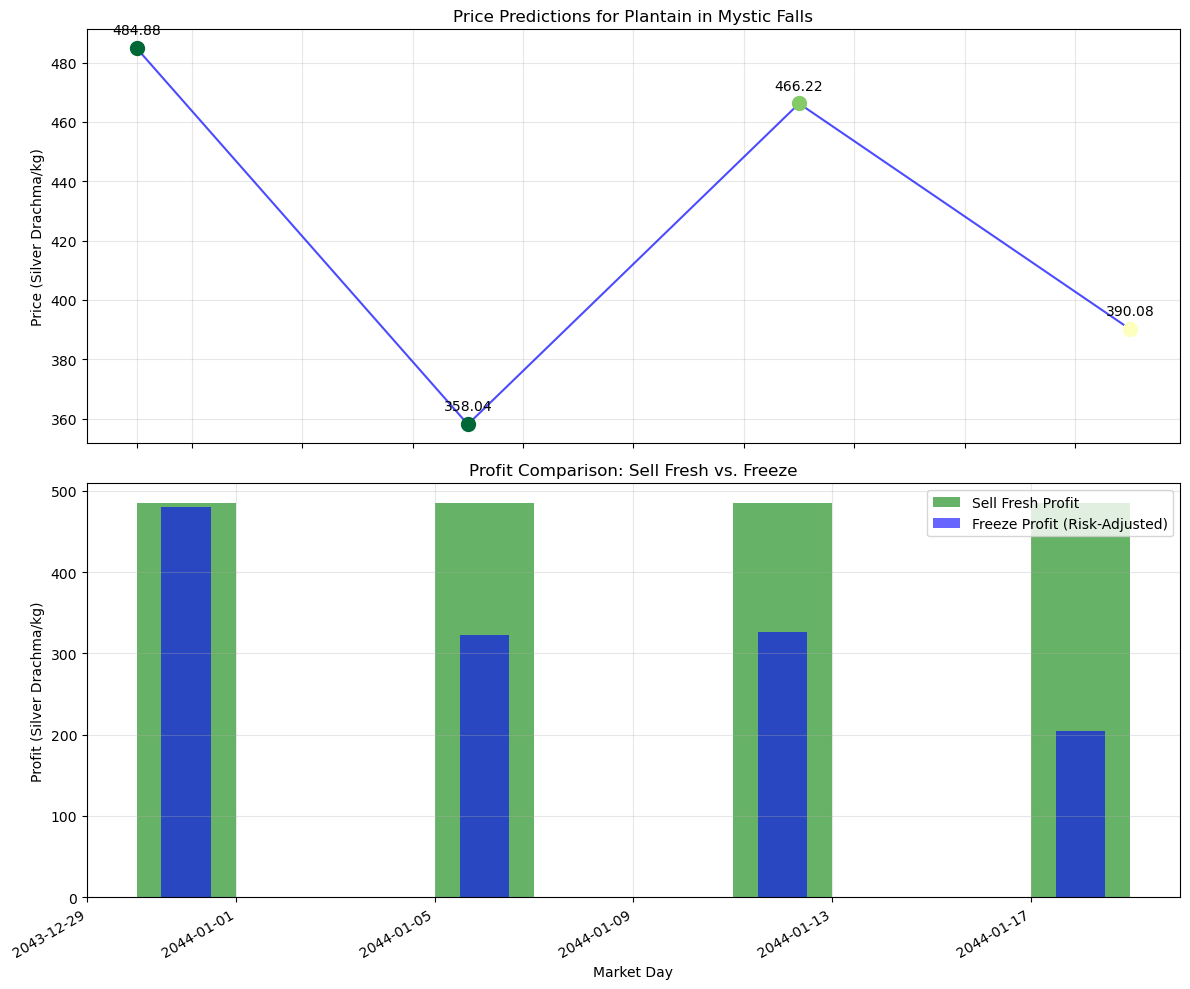

In [66]:
# Visualize predictions for the sample region and commodity
visualize_predictions(sample_region, sample_commodity, current_date)


In [67]:

# Analyze model performance across different regions and commodities
def analyze_model_performance():
    """
    Analyzes model performance across different regions and commodities
    """
    # Evaluate the model
    evaluation = model.evaluate(weather_eval, price_eval)
    
    if len(evaluation) == 0:
        print("No evaluation data available")
        return
    
    # Calculate average errors by region
    region_performance = evaluation.groupby('Region').agg({
        'MAE': 'mean',
        'RMSE': 'mean',
        'Samples': 'sum'
    }).sort_values('MAE')
    
    # Calculate average errors by commodity
    commodity_performance = evaluation.groupby('Commodity').agg({
        'MAE': 'mean',
        'RMSE': 'mean',
        'Samples': 'sum'
    }).sort_values('MAE')
    
    # Plot performance by region
    plt.figure(figsize=(14, 8))
    
    # Only plot top 10 regions for readability
    top_regions = region_performance.head(10)
    sns.barplot(x=top_regions.index, y=top_regions['MAE'])
    plt.title('Model Performance by Region (Top 10)')
    plt.xlabel('Region')
    plt.ylabel('Mean Absolute Error')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Plot performance by commodity
    plt.figure(figsize=(14, 8))
    
    # Only plot top 10 commodities for readability
    top_commodities = commodity_performance.head(10)
    sns.barplot(x=top_commodities.index, y=top_commodities['MAE'])
    plt.title('Model Performance by Commodity (Top 10)')
    plt.xlabel('Commodity')
    plt.ylabel('Mean Absolute Error')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return region_performance, commodity_performance


100%|██████████| 925/925 [00:43<00:00, 21.24it/s]


Average MAE: 8.04
Average RMSE: 13.15


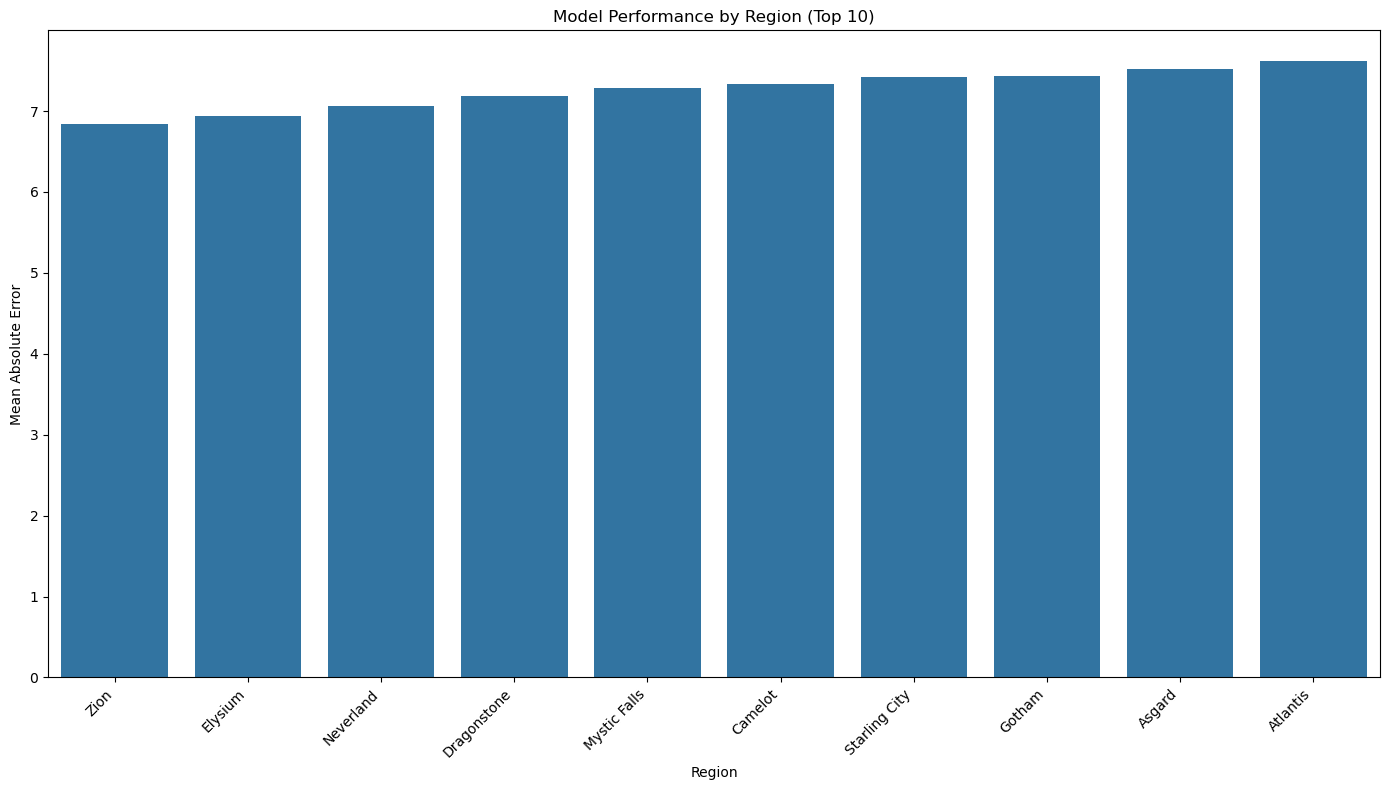

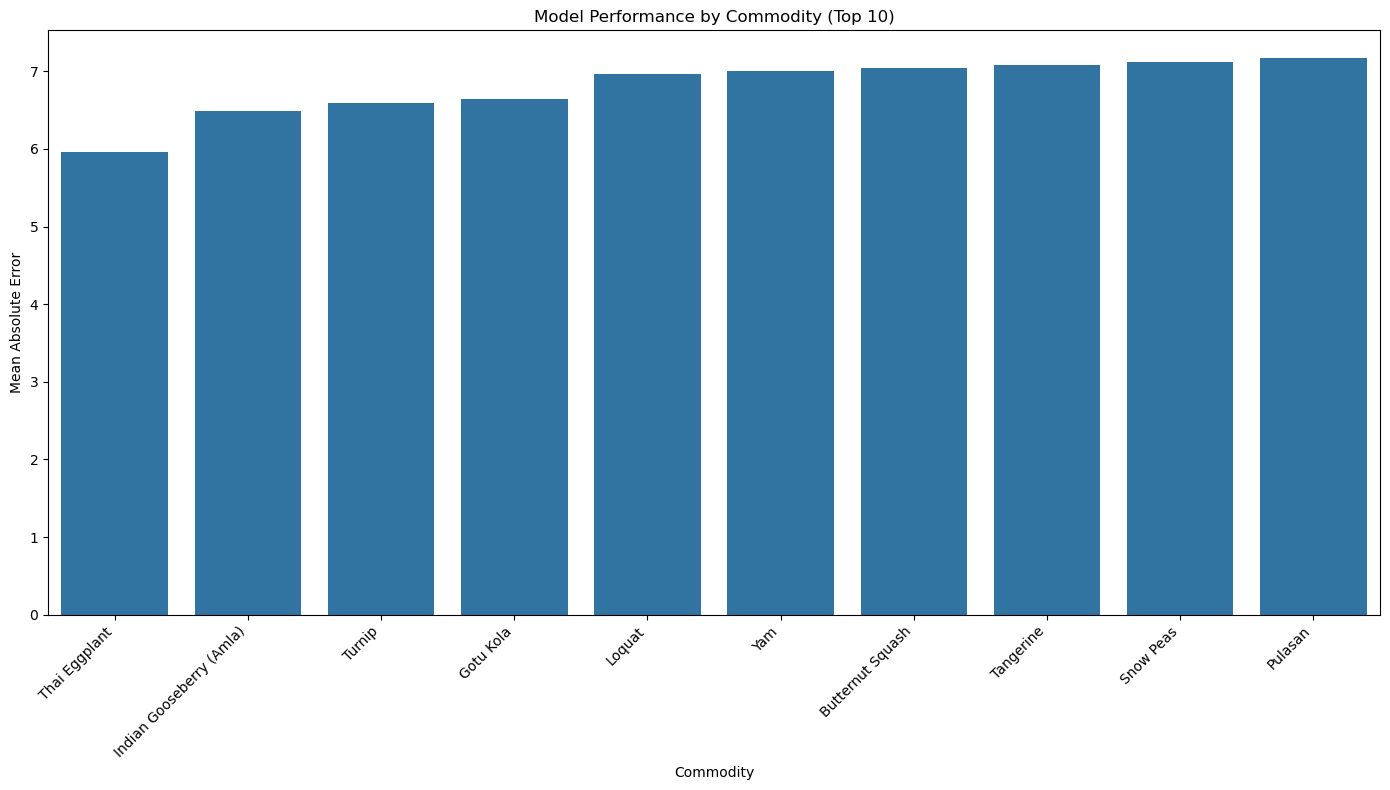


Best performing regions:
                   MAE       RMSE  Samples
Region                                    
Zion          6.845341  11.094858      888
Elysium       6.935618  10.857173      888
Neverland     7.059706  11.676777      888
Dragonstone   7.189952  12.029954      888
Mystic Falls  7.280724  11.766023      888

Best performing commodities:
                               MAE       RMSE  Samples
Commodity                                             
Thai Eggplant             5.965881   9.142062      550
Indian Gooseberry (Amla)  6.492144  10.286316      650
Turnip                    6.588142  10.398654      550
Gotu Kola                 6.640948  10.580767      550
Loquat                    6.959743  11.188267      650


In [68]:
# Analyze model performance
region_perf, commodity_perf = analyze_model_performance()

print("\nBest performing regions:")
print(region_perf.head())

print("\nBest performing commodities:")
print(commodity_perf.head())


In [69]:
def get_predictions(region, commodity, current_date, model=None, weather_data=weather_eval):
    """
    Get price predictions for a specific region, commodity, and date
    
    Parameters:
    -----------
    region : str
        The market region
    commodity : str
        The agricultural product
    current_date : str or datetime
        The current date (format: 'YYYY-MM-DD')
    model : HybridForecastingModel, optional
        The trained model (if None, will use the global model)
    weather_data : DataFrame, optional
        Weather data to use for predictions (defaults to weather_eval)
        
    Returns:
    --------
    DataFrame with predictions and confidence levels
    """
    # Convert date to datetime if it's a string
    if isinstance(current_date, str):
        current_date = pd.to_datetime(current_date)
    
    # Use global model if none provided
    if model is None:
        if 'model' not in globals():
            print("No model available. Please train the model first using main()")
            return None
        model = globals()['model']
    
    # Get predictions
    predictions = model.predict(region, commodity, current_date, weather_data)
    
    if predictions is None:
        print(f"Could not generate predictions for {commodity} in {region}")
        return None
    
    print(f"\nPrice predictions for {commodity} in {region} from {current_date.strftime('%Y-%m-%d')}:")
    for _, row in predictions.iterrows():
        print(f"Market Day: {row['Market Day'].strftime('%Y-%m-%d')}")
        print(f"Predicted Price: {row['Predicted Price (Silver Drachma/kg)']:.2f} Silver Drachma/kg")
        print(f"Confidence: {row['Confidence']}")
        print("-" * 40)
    
    # Also provide decision support
    decision_analysis = magnus_decision_support(
        region=region,
        commodity=commodity,
        current_date=current_date,
        freezing_cost=5,
        weekly_depreciation_rate=0.1
    )
    
    # Create a visualization
    visualize_predictions(region, commodity, current_date)
    
    return predictions


Using existing trained model

Price predictions for Amaranth Leaves in Metropolis from 2043-12-31:
Market Day: 2044-01-02
Predicted Price: 192.94 Silver Drachma/kg
Confidence: High
----------------------------------------
Market Day: 2044-01-09
Predicted Price: 463.41 Silver Drachma/kg
Confidence: Medium-High
----------------------------------------
Market Day: 2044-01-16
Predicted Price: 261.91 Silver Drachma/kg
Confidence: Medium
----------------------------------------
Market Day: 2044-01-23
Predicted Price: 227.34 Silver Drachma/kg
Confidence: Medium-Low
----------------------------------------

✅ RECOMMENDATION: FREEZE Amaranth Leaves and sell on 2044-01-09
Expected profit increase: 146.81 Silver Drachma/kg

✅ RECOMMENDATION: FREEZE Amaranth Leaves and sell on 2044-01-09
Expected profit increase: 146.81 Silver Drachma/kg


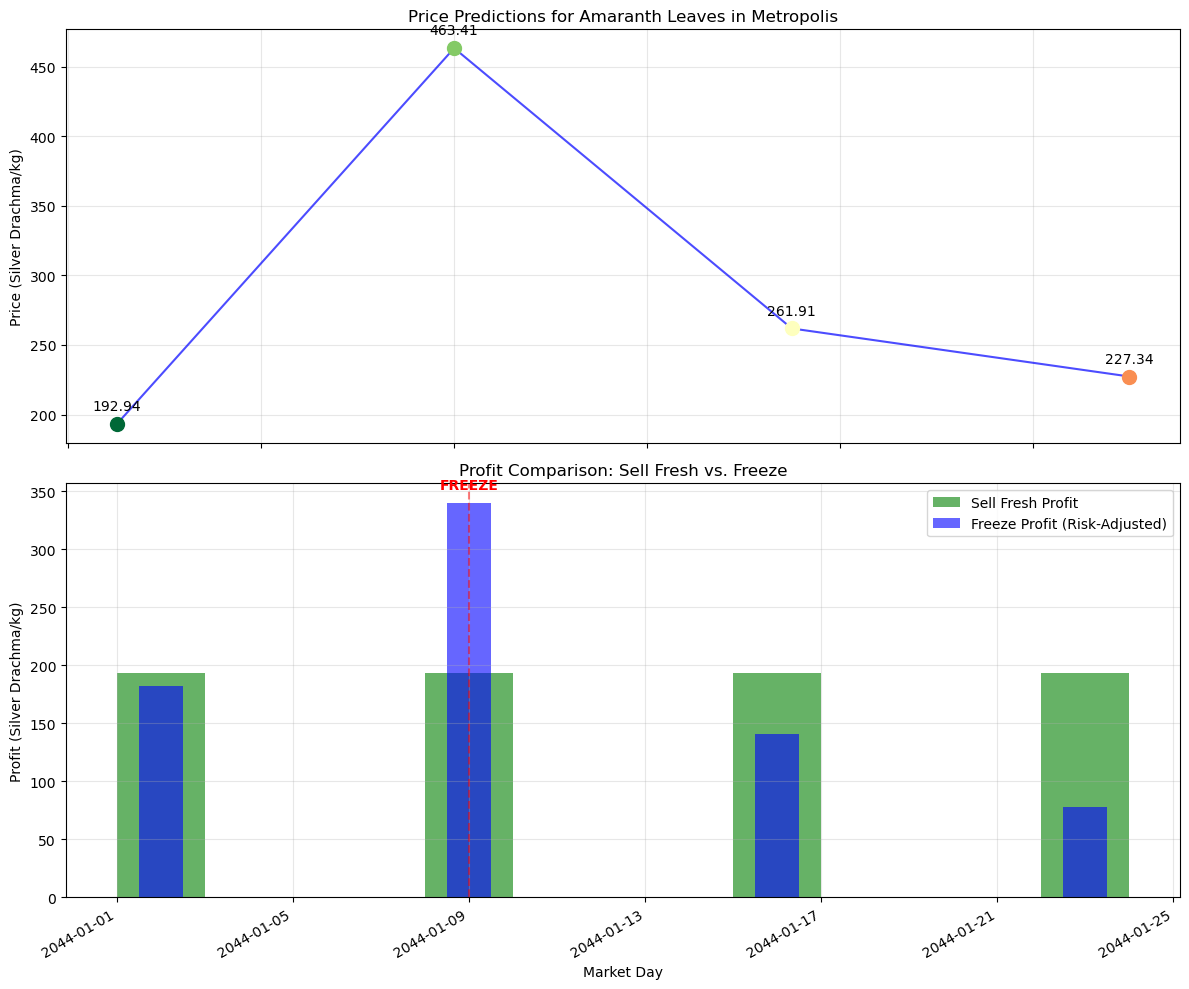

In [70]:
# First make sure you've trained the model
if 'model' not in globals() or not isinstance(model, HybridForecastingModel):
    print("Training the model first...")
    model, predict_for_magnus = main()
else:
    print("Using existing trained model")

# Example: Get predictions for a specific region, commodity, and date
# Replace these with actual values from your dataset
region = price_train['Region'].iloc[0]  
commodity = price_train['Commodity'].iloc[0]
date = weather_eval['Date'].max()

# Get predictions
predictions = get_predictions("Metropolis", "Amaranth Leaves", "2043-12-31")


In [71]:
# Data Pipeline for Continuous Model Updates
class AgriculturalDataPipeline:
    """
    Pipeline for ingesting new data and updating the forecasting model
    
    This pipeline handles:
    1. Ingestion of new weather and price data
    2. Model adaptation strategies (retraining or fine-tuning)
    3. Rolling predictions for upcoming market days
    """
    
    def __init__(self, model=None, update_strategy='periodic_retrain', 
                 update_frequency=4, fine_tune_window=8):
        """
        Initialize the data pipeline
        
        Parameters:
        -----------
        model : HybridForecastingModel, optional
            Pre-trained model (if None, a new model will be created)
        update_strategy : str, optional
            Strategy for model updates ('periodic_retrain', 'online_learning', 'fine_tuning')
        update_frequency : int, optional
            How often to update the model (in weeks)
        fine_tune_window : int, optional
            Window size for fine-tuning (in weeks)
        """
        # Use provided model or create a new one
        if model is None:
            self.model = HybridForecastingModel()
            self.is_trained = False
        else:
            self.model = model
            self.is_trained = True
            
        # Pipeline settings
        self.update_strategy = update_strategy
        self.update_frequency = update_frequency
        self.fine_tune_window = fine_tune_window
        
        # Data tracking
        self.last_update_date = None
        self.weeks_since_update = 0
        self.historical_weather = None
        self.historical_prices = None
        
        # Performance tracking
        self.prediction_history = []
        self.performance_metrics = []
    
    def initialize_with_historical_data(self, weather_data, price_data):
        """
        Initialize the pipeline with historical data and train initial model
        
        Parameters:
        -----------
        weather_data : DataFrame
            Historical weather data
        price_data : DataFrame
            Historical price data
        """
        self.historical_weather = weather_data.copy()
        self.historical_prices = price_data.copy()
        
        # Get the latest date in the data
        self.last_update_date = weather_data['Date'].max()
        
        # Train the model if not already trained
        if not self.is_trained:
            print("Training initial model with historical data...")
            self.model.fit(weather_data, price_data)
            self.is_trained = True
        
        print(f"Pipeline initialized with data up to {self.last_update_date}")
    
    def ingest_new_data(self, new_weather_data, new_price_data):
        """
        Ingest new weather and price data
        
        Parameters:
        -----------
        new_weather_data : DataFrame
            New weather data to ingest
        new_price_data : DataFrame
            New price data to ingest
            
        Returns:
        --------
        bool : Whether new data was successfully ingested
        """
        if self.historical_weather is None or self.historical_prices is None:
            print("Error: Pipeline not initialized with historical data")
            return False
        
        # Validate new data
        if len(new_weather_data) == 0 or len(new_price_data) == 0:
            print("Warning: Empty data provided")
            return False
        
        # Check if new data is actually newer than what we have
        max_new_date = new_weather_data['Date'].max()
        if max_new_date <= self.last_update_date:
            print(f"Warning: New data (up to {max_new_date}) is not newer than existing data (up to {self.last_update_date})")
            return False
        
        # Calculate weeks since last update
        weeks_diff = (max_new_date - self.last_update_date).days // 7
        self.weeks_since_update += weeks_diff
        
        # Append new data to historical data
        self.historical_weather = pd.concat([self.historical_weather, new_weather_data]).drop_duplicates()
        self.historical_prices = pd.concat([self.historical_prices, new_price_data]).drop_duplicates()
        
        # Update the last update date
        self.last_update_date = max_new_date
        
        print(f"Ingested new data up to {max_new_date} ({len(new_weather_data)} weather records, {len(new_price_data)} price records)")
        
        # Check if model update is needed
        self._check_for_model_update()
        
        return True
    
    def _check_for_model_update(self):
        """
        Check if model update is needed based on update strategy and frequency
        """
        if self.update_strategy == 'periodic_retrain' and self.weeks_since_update >= self.update_frequency:
            print(f"Performing periodic retraining after {self.weeks_since_update} weeks")
            self._retrain_model()
            self.weeks_since_update = 0
            
        elif self.update_strategy == 'fine_tuning' and self.weeks_since_update >= self.update_frequency:
            print(f"Performing model fine-tuning after {self.weeks_since_update} weeks")
            self._fine_tune_model()
            self.weeks_since_update = 0
            
        elif self.update_strategy == 'online_learning':
            print("Performing online learning with new data")
            self._online_learning()
            self.weeks_since_update = 0
    
    def _retrain_model(self):
        """
        Completely retrain the model with all historical data
        """
        print("Retraining model with all historical data...")
        self.model = HybridForecastingModel()  # Create a new model instance
        self.model.fit(self.historical_weather, self.historical_prices)
        
        # Evaluate model after retraining
        self._evaluate_current_model()
    
    def _fine_tune_model(self):
        """
        Fine-tune the existing model with recent data
        """
        # Get recent data for fine-tuning
        recent_date_cutoff = self.last_update_date - pd.Timedelta(days=7 * self.fine_tune_window)
        recent_weather = self.historical_weather[self.historical_weather['Date'] >= recent_date_cutoff]
        recent_prices = self.historical_prices[self.historical_prices['Date'] >= recent_date_cutoff]
        
        print(f"Fine-tuning model with data from {recent_date_cutoff} to {self.last_update_date}")
        
        # For each region-commodity pair, update the LightGBM model
        for (region, commodity), lgb_model in self.model.lgb_models.items():
            # Create features for this region-commodity
            features = create_weather_features(recent_weather, recent_prices, self.model.market_patterns)
            
            if (region, commodity) not in features:
                continue
                
            data = features[(region, commodity)]
            
            # Select features and target
            feature_cols = [col for col in data.columns if any(x in col for x in ['Temp', 'Rain', 'Humidity', 'Impact', 'prophet'])]
            feature_cols = [col for col in feature_cols if 'lag' in col or 'roll' in col or 'prophet' in col]
            
            # Remove rows with NaN
            train_data = data.dropna(subset=feature_cols + ['Price per Unit (Silver Drachma/kg)'])
            
            if len(train_data) < 5:
                continue
                
            # Scale features
            X = train_data[feature_cols]
            y = train_data['Price per Unit (Silver Drachma/kg)']
            
            X_scaled = self.model.scalers[(region, commodity)].transform(X)
            
            # Update the model with new data (partial_fit equivalent for LightGBM)
            # We create a new model and merge predictions with the old one
            new_model = lgb.train(
                self.model.lgb_params, 
                lgb.Dataset(X_scaled, label=y),
                num_boost_round=50  # Fewer rounds for fine-tuning
            )
            
            # Update the model (weighted average of old and new predictions)
            # This is a simple approach - in production you might use more sophisticated methods
            alpha = 0.3  # Weight for new model (0.3 means 30% new, 70% old)
            
            # We can't directly combine LightGBM models, so we'll update during prediction time
            # Store both models and the alpha value
            self.model.lgb_models[(region, commodity)] = {
                'old_model': lgb_model,
                'new_model': new_model,
                'alpha': alpha
            }
        
        # Evaluate model after fine-tuning
        self._evaluate_current_model()
    
    def _online_learning(self):
        """
        Perform online learning with the most recent data
        """
        # Get only the new data since last update
        new_date_cutoff = self.last_update_date - pd.Timedelta(days=7 * self.update_frequency)
        new_weather = self.historical_weather[self.historical_weather['Date'] >= new_date_cutoff]
        new_prices = self.historical_prices[self.historical_prices['Date'] >= new_date_cutoff]
        
        print(f"Performing online learning with data from {new_date_cutoff} to {self.last_update_date}")
        
        # Update Prophet models with new data
        for (region, commodity) in self.model.prophet_models.keys():
            # Filter data for this region-commodity
            region_prices = new_prices[(new_prices['Region'] == region) & 
                                      (new_prices['Commodity'] == commodity)]
            
            if len(region_prices) < 5:
                continue
                
            # Prepare data for Prophet
            prophet_data = region_prices[['Date', 'Price per Unit (Silver Drachma/kg)']].rename(
                columns={'Date': 'ds', 'Price per Unit (Silver Drachma/kg)': 'y'}
            )
            
            # Update the Prophet model
            # Prophet doesn't support true online learning, so we'll use a workaround
            # We'll update the model with a small number of iterations
            self.model.prophet_models[(region, commodity)].fit(prophet_data, iter=100)
        
        # Now update LightGBM models similar to fine-tuning
        self._fine_tune_model()
    
    def _evaluate_current_model(self):
        """
        Evaluate the current model and track performance
        """
        # Use the most recent data as evaluation data
        eval_cutoff = self.last_update_date - pd.Timedelta(days=28)  # Last 4 weeks
        weather_eval = self.historical_weather[self.historical_weather['Date'] >= eval_cutoff]
        price_eval = self.historical_prices[self.historical_prices['Date'] >= eval_cutoff]
        
        # Evaluate the model
        evaluation = self.model.evaluate(weather_eval, price_eval, save_comparison=False)
        
        # Track performance
        avg_mae = evaluation['MAE'].mean() if len(evaluation) > 0 else float('nan')
        avg_rmse = evaluation['RMSE'].mean() if len(evaluation) > 0 else float('nan')
        
        self.performance_metrics.append({
            'Date': self.last_update_date,
            'Strategy': self.update_strategy,
            'MAE': avg_mae,
            'RMSE': avg_rmse,
            'Samples': evaluation['Samples'].sum() if len(evaluation) > 0 else 0
        })
        
        print(f"Model evaluation after update - MAE: {avg_mae:.2f}, RMSE: {avg_rmse:.2f}")
    
    def make_rolling_predictions(self, current_date=None, weeks_ahead=4):
        """
        Make rolling predictions for the specified number of weeks ahead
        
        Parameters:
        -----------
        current_date : datetime or str, optional
            Date to use as reference (defaults to last update date)
        weeks_ahead : int, optional
            Number of weeks to predict ahead (default: 4)
            
        Returns:
        --------
        dict : Dictionary of predictions by region-commodity pair
        """
        if current_date is None:
            current_date = self.last_update_date
        elif isinstance(current_date, str):
            current_date = pd.to_datetime(current_date)
        
        # Get all unique region-commodity pairs
        region_commodities = []
        for region in self.historical_prices['Region'].unique():
            for commodity in self.historical_prices[self.historical_prices['Region'] == region]['Commodity'].unique():
                region_commodities.append((region, commodity))
        
        # Make predictions for each region-commodity pair
        all_predictions = {}
        
        for region, commodity in region_commodities:
            if (region, commodity) not in self.model.prophet_models or \
               (region, commodity) not in self.model.lgb_models:
                continue
            
            # Get predictions
            predictions = self.model.predict(region, commodity, current_date, self.historical_weather)
            
            if predictions is not None:
                all_predictions[(region, commodity)] = predictions
                
                # Store prediction history for tracking
                for _, row in predictions.iterrows():
                    self.prediction_history.append({
                        'Region': region,
                        'Commodity': commodity,
                        'Prediction_Date': current_date,
                        'Market_Day': row['Market Day'],
                        'Predicted_Price': row['Predicted Price (Silver Drachma/kg)'],
                        'Confidence': row['Confidence']
                    })
        
        return all_predictions
    
    def get_performance_trend(self):
        """
        Get the performance trend of the model over time
        
        Returns:
        --------
        DataFrame : Performance metrics over time
        """
        return pd.DataFrame(self.performance_metrics)
    
    def save_pipeline_state(self, filename='agrochill_pipeline.pkl'):
        """
        Save the entire pipeline state to a file
        
        Parameters:
        -----------
        filename : str, optional
            Filename to save to
        """
        state = {
            'model': self.model,
            'is_trained': self.is_trained,
            'update_strategy': self.update_strategy,
            'update_frequency': self.update_frequency,
            'fine_tune_window': self.fine_tune_window,
            'last_update_date': self.last_update_date,
            'weeks_since_update': self.weeks_since_update,
            'historical_weather': self.historical_weather,
            'historical_prices': self.historical_prices,
            'prediction_history': self.prediction_history,
            'performance_metrics': self.performance_metrics
        }
        
        with open(filename, 'wb') as f:
            pickle.dump(state, f)
        
        print(f"Pipeline state saved to {filename}")
    
    def load_pipeline_state(self, filename='agrochill_pipeline.pkl'):
        """
        Load the pipeline state from a file
        
        Parameters:
        -----------
        filename : str, optional
            Filename to load from
            
        Returns:
        --------
        bool : Whether the state was successfully loaded
        """


In [72]:
# Import inspect module for function serialization
import inspect
import os

# Modified save function that handles the local functionokay  issue
def save_complete_system_fixed(filename='agrochill_complete_system.pkl'):
    """
    Saves the entire forecasting system including model and pipeline to a file,
    handling the local function issue
    """
    # Create the pipeline with the trained model
    pipeline = AgriculturalDataPipeline(model=model)
    
    # Initialize with the training data
    pipeline.initialize_with_historical_data(weather_train, price_train)
    
    # Create a dictionary with all important components except the local function
    complete_system = {
        'model': model,
        'pipeline': pipeline,
        'weather_train': weather_train,
        'price_train': price_train,
        'weather_eval': weather_eval,
        'price_eval': price_eval,
        'creation_date': pd.Timestamp.now(),
        # Add this line to save the magnus_decision_support function
        'magnus_decision_support_code': inspect.getsource(magnus_decision_support)
    }
    
    # Save to file
    with open(filename, 'wb') as f:
        pickle.dump(complete_system, f)
    
    print(f"Complete forecasting system saved to {filename}")
    print(f"Full path: {os.path.abspath(filename)}")
    return True

# Function to load the complete system and recreate the prediction function
def load_complete_system_fixed(filename='agrochill_complete_system.pkl'):
    """
    Loads the entire forecasting system from a file and recreates the prediction function
    """
    try:
        with open(filename, 'rb') as f:
            complete_system = pickle.load(f)
            
        print(f"Complete forecasting system loaded from {filename}")
        print(f"System was created on: {complete_system['creation_date']}")
            
        # Extract components to global namespace
        globals()['model'] = complete_system['model']
        globals()['pipeline'] = complete_system['pipeline']
        globals()['weather_train'] = complete_system['weather_train']
        globals()['price_train'] = complete_system['price_train']
        globals()['weather_eval'] = complete_system['weather_eval']
        globals()['price_eval'] = complete_system['price_eval']
            
        # Recreate the predict_for_magnus function
        def recreated_predict_for_magnus(region, commodity, current_date):
            """Recreated prediction function"""
            return model.predict(region, commodity, current_date, weather_eval)
            
        globals()['predict_for_magnus'] = recreated_predict_for_magnus
        
        # Recreate the magnus_decision_support function
        if 'magnus_decision_support_code' in complete_system:
            exec(complete_system['magnus_decision_support_code'], globals())
            
        return complete_system
    except Exception as e:
        print(f"Error loading complete system: {e}")
        return None

# Save the complete system with the fixed approach
save_complete_system_fixed()


Pipeline initialized with data up to 2043-06-30 00:00:00
Complete forecasting system saved to agrochill_complete_system.pkl
Full path: c:\Users\L E N O V O\Downloads\New folder\agrochill_complete_system.pkl


True